<a href="https://colab.research.google.com/github/Tamannapanwar17/credit-card-fraud-detection/blob/main/Credit_Card_Fraud_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Problem Understanding

## Define the Problem:

Credit Card Fraud Detection

Credit card fraud is a major challenge for banks and financial institutions, leading to significant financial losses each year. Fraudulent transactions are rare compared to legitimate ones, making fraud detection a highly imbalanced binary classification problem.

The objective of this project is to develop a machine learning model capable of accurately identifying fraudulent transactions while minimizing false alarms. Since fraudulent transactions represent only a very small fraction of the dataset, special techniques such as SMOTE will be used to address class imbalance.

The final model will be optimized and deployed as a Streamlit web application for real-time fraud prediction.

# Data Collection

In [64]:
from google.colab import files

uploaded = files.upload()

Saving creditcard.csv.zip to creditcard.csv (3).zip


In [6]:
import zipfile

with zipfile.ZipFile('creditcard.csv.zip', 'r') as zip_ref:
    zip_ref.extractall()

In [7]:
import os

os.listdir()

['.config',
 'creditcard.csv',
 'creditcard.csv.zip',
 'creditcard.csv (1).zip',
 'sample_data']

In [8]:
import pandas as pd

df = pd.read_csv('creditcard.csv')

# Data Understanding

In [9]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [10]:
df.shape

(284807, 31)

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [12]:
df.isnull().sum()

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


In [13]:
df['Class'].value_counts()

,count
Class,
0,284315
1,492


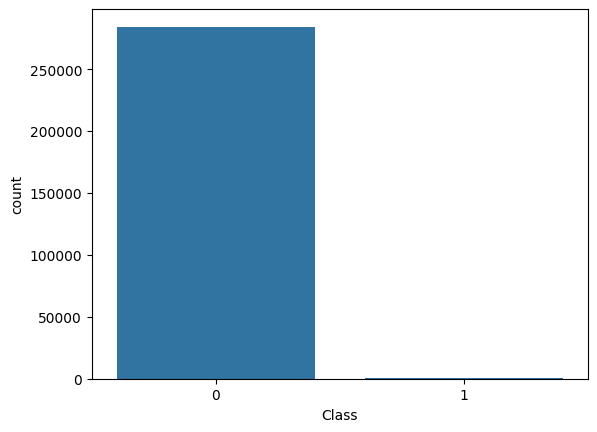

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Class', data=df)
plt.show()

In [15]:
print(df['Class'].value_counts(normalize=True)*100)

Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64


#Class	Percentage
#####Legitimate	99.83%
#####Fraud	0.17%

In [16]:
df['Amount'].describe()

,Amount
count,284807.000000
mean,88.349619
std,250.120109
min,0.000000
25%,5.600000
50%,22.000000
75%,77.165000
max,25691.160000


######**Count (284807):** No missing values in Amount.
#####**Mean (88.35)**: Average transaction amount.
#####**Median (22.00)**: Half of transactions are below 22.
#####**Max (25691.16)**: Very large transactions exist.
#####**Standard deviation (250.12)**: High variability in transaction amounts.

The mean being much higher than the median suggests the distribution is right-skewed because of a few very large transactions.

In [17]:
df.duplicated().sum()

np.int64(1081)

In [18]:
df = df.drop_duplicates()

In [19]:
df.duplicated().sum()

np.int64(0)

In [20]:
df.shape

(283726, 31)

In [21]:
df["Class"].value_counts()

,count
Class,
0,283253
1,473


In [22]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,...,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000
mean,94811.077600,0.005917,-0.004135,0.001613,-0.002966,0.001828,-0.001139,0.001801,-0.000854,-0.001596,...,-0.000371,-0.000015,0.000198,0.000214,-0.000232,0.000149,0.001763,0.000547,88.472687,0.001667
std,47481.047891,1.948026,1.646703,1.508682,1.414184,1.377008,1.331931,1.227664,1.179054,1.095492,...,0.723909,0.724550,0.623702,0.605627,0.521220,0.482053,0.395744,0.328027,250.399437,0.040796
min,0.000000,-56.407510,-72.715728,-48.325589,-5.683171,-113.743307,-26.160506,-43.557242,-73.216718,-13.434066,...,-34.830382,-10.933144,-44.807735,-2.836627,-10.295397,-2.604551,-22.565679,-15.430084,0.000000,0.000000
25%,54204.750000,-0.915951,-0.600321,-0.889682,-0.850134,-0.689830,-0.769031,-0.552509,-0.208828,-0.644221,...,-0.228305,-0.542700,-0.161703,-0.354453,-0.317485,-0.326763,-0.070641,-0.052818,5.600000,0.000000
50%,84692.500000,0.020384,0.063949,0.179963,-0.022248,-0.053468,-0.275168,0.040859,0.021898,-0.052596,...,-0.029441,0.006675,-0.011159,0.041016,0.016278,-0.052172,0.001479,0.011288,22.000000,0.000000
75%,139298.000000,1.316068,0.800283,1.026960,0.739647,0.612218,0.396792,0.570474,0.325704,0.595977,...,0.186194,0.528245,0.147748,0.439738,0.350667,0.240261,0.091208,0.078276,77.510000,0.000000
max,172792.000000,2.454930,22.057729,9.382558,16.875344,34.801666,73.301626,120.589494,20.007208,15.594995,...,27.202839,10.503090,22.528412,4.584549,7.519589,3.517346,31.612198,33.847808,25691.160000,1.000000


In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 283726 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    283726 non-null  float64
 1   V1      283726 non-null  float64
 2   V2      283726 non-null  float64
 3   V3      283726 non-null  float64
 4   V4      283726 non-null  float64
 5   V5      283726 non-null  float64
 6   V6      283726 non-null  float64
 7   V7      283726 non-null  float64
 8   V8      283726 non-null  float64
 9   V9      283726 non-null  float64
 10  V10     283726 non-null  float64
 11  V11     283726 non-null  float64
 12  V12     283726 non-null  float64
 13  V13     283726 non-null  float64
 14  V14     283726 non-null  float64
 15  V15     283726 non-null  float64
 16  V16     283726 non-null  float64
 17  V17     283726 non-null  float64
 18  V18     283726 non-null  float64
 19  V19     283726 non-null  float64
 20  V20     283726 non-null  float64
 21  V21     283726 

# Exploratory Data Analysis (EDA)

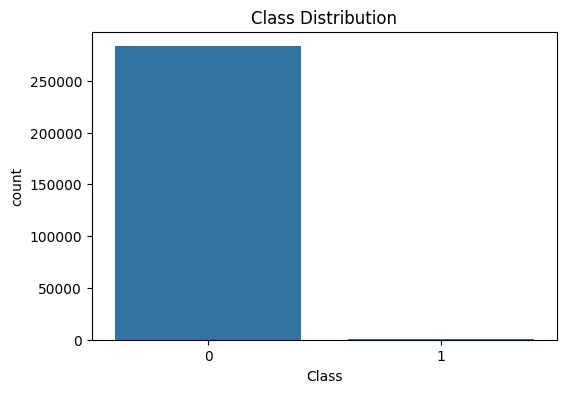

In [24]:
plt.figure(figsize=(6,4))

sns.countplot(x="Class", data=df)

plt.title("Class Distribution")

plt.show()

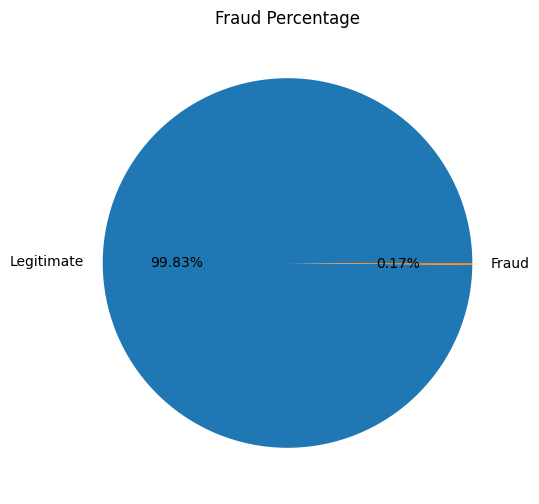

In [25]:
fraud=df["Class"].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    fraud,
    labels=["Legitimate","Fraud"],
    autopct="%1.2f%%"
)

plt.title("Fraud Percentage")

plt.show()

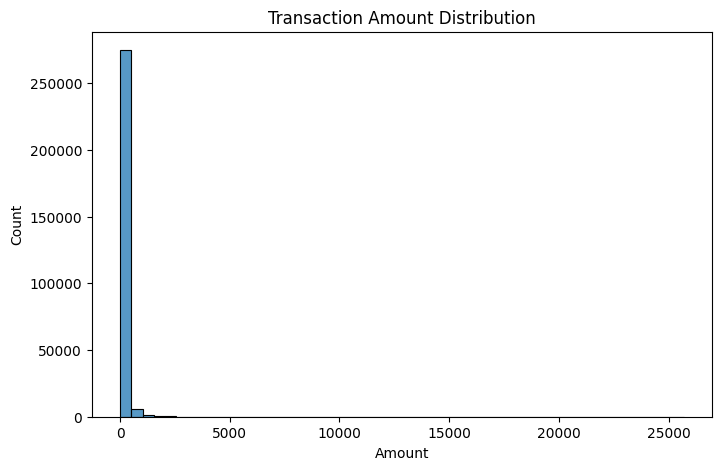

In [26]:
plt.figure(figsize=(8,5))

sns.histplot(df["Amount"],bins=50)

plt.title("Transaction Amount Distribution")

plt.show()

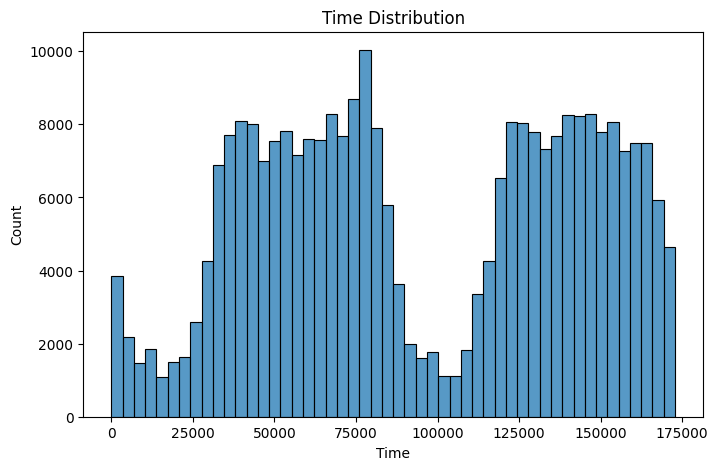

In [27]:
plt.figure(figsize=(8,5))

sns.histplot(df["Time"],bins=50)

plt.title("Time Distribution")

plt.show()

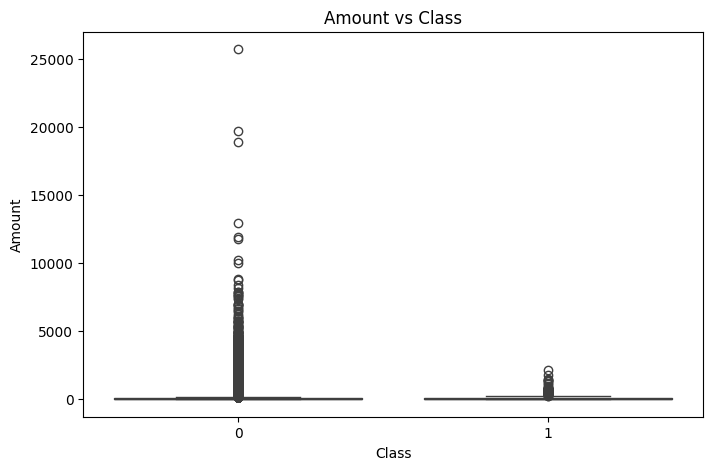

In [28]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="Class",
    y="Amount",
    data=df
)

plt.title("Amount vs Class")

plt.show()

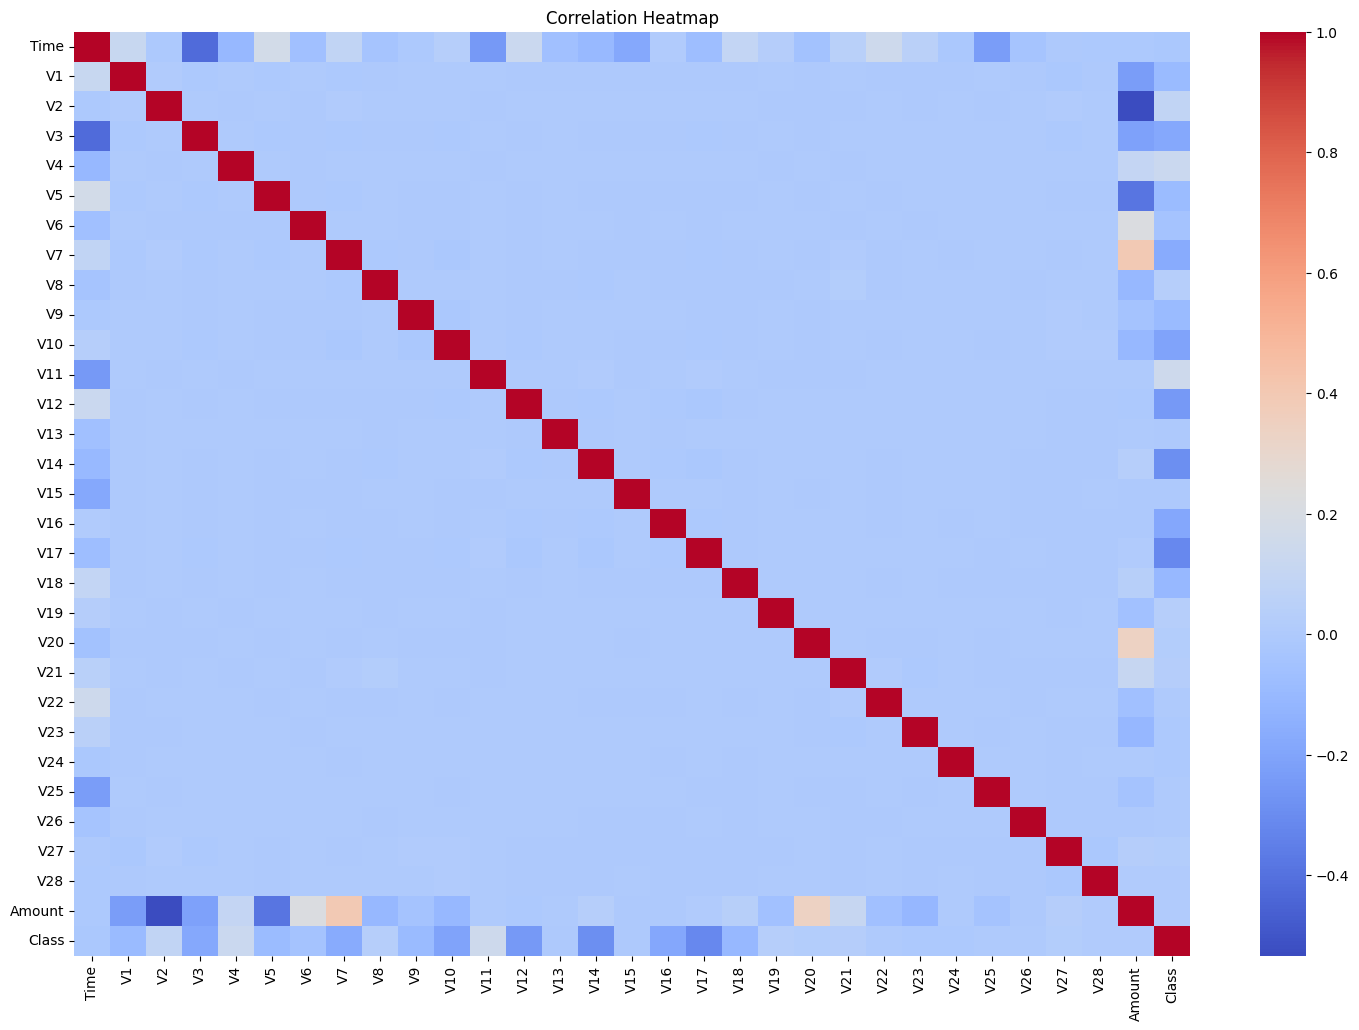

In [29]:
plt.figure(figsize=(18,12))

sns.heatmap(
    df.corr(),
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

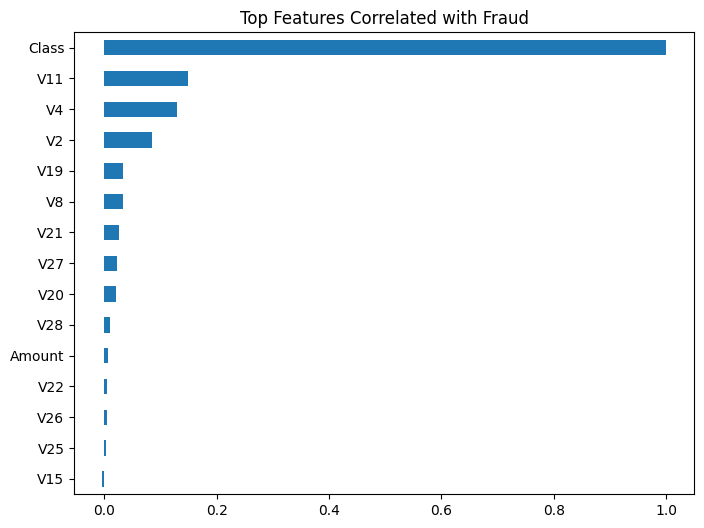

In [30]:
corr=df.corr()["Class"].sort_values()

corr.tail(15).plot(kind="barh",figsize=(8,6))

plt.title("Top Features Correlated with Fraud")

plt.show()

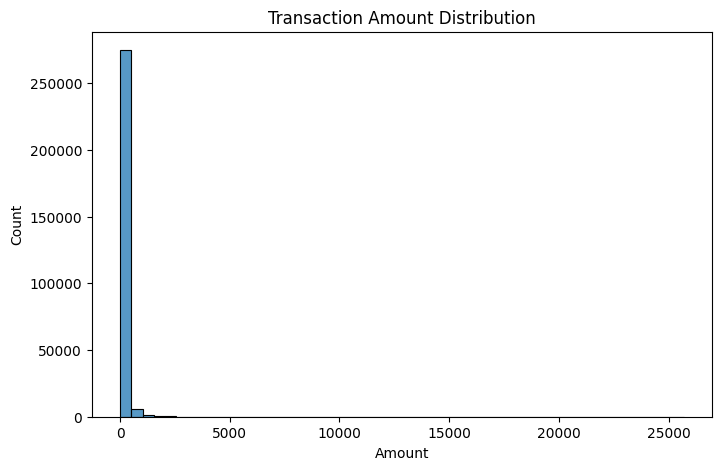

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.histplot(df['Amount'], bins=50)
plt.title('Transaction Amount Distribution')
plt.show()

# Data Preprocessing

In [32]:
from sklearn.preprocessing import StandardScaler

scaler=StandardScaler()

df["Amount"]=scaler.fit_transform(df[["Amount"]])


In [33]:
df.drop('Time', axis=1, inplace=True)

In [34]:
X = df.drop('Class', axis=1)
y = df['Class']

# Train - Test Split

In [35]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [36]:
print(y_train.value_counts())
print(y_test.value_counts())

Class
0    226602
1       378
Name: count, dtype: int64
Class
0    56651
1       95
Name: count, dtype: int64


# Handle Imbalanced Data

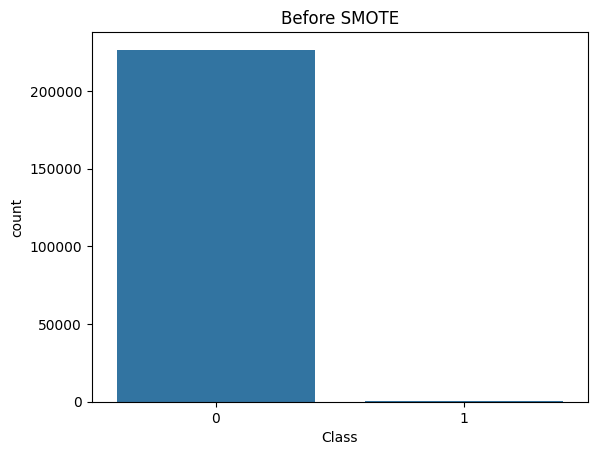

In [37]:
sns.countplot(x=y_train)

plt.title("Before SMOTE")

plt.show()

In [38]:
from imblearn.over_sampling import SMOTE

smote=SMOTE(random_state=42)

X_train_smote,y_train_smote=smote.fit_resample(
    X_train,
    y_train
)

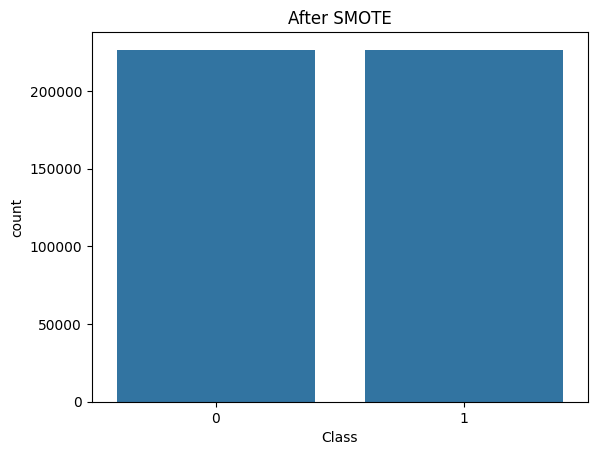

In [39]:
sns.countplot(x=y_train_smote)

plt.title("After SMOTE")

plt.show()

# Baseline Models

In [40]:
from sklearn.linear_model import LogisticRegression

lr=LogisticRegression(max_iter=1000)

lr.fit(X_train,y_train)

LogisticRegression(max_iter=1000)

In [41]:
from sklearn.tree import DecisionTreeClassifier

dt=DecisionTreeClassifier(random_state=42)

dt.fit(X_train,y_train)

DecisionTreeClassifier(random_state=42)

In [42]:
from sklearn.ensemble import RandomForestClassifier

rf=RandomForestClassifier(random_state=42)

rf.fit(X_train,y_train)

RandomForestClassifier(random_state=42)

In [44]:
from xgboost import XGBClassifier

xgb=XGBClassifier(random_state=42)

xgb.fit(X_train,y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

# Model Evaluation

In [45]:
from sklearn.metrics import classification_report

pred=rf.predict(X_test)

print(classification_report(y_test,pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.97      0.74      0.84        95

    accuracy                           1.00     56746
   macro avg       0.99      0.87      0.92     56746
weighted avg       1.00      1.00      1.00     56746



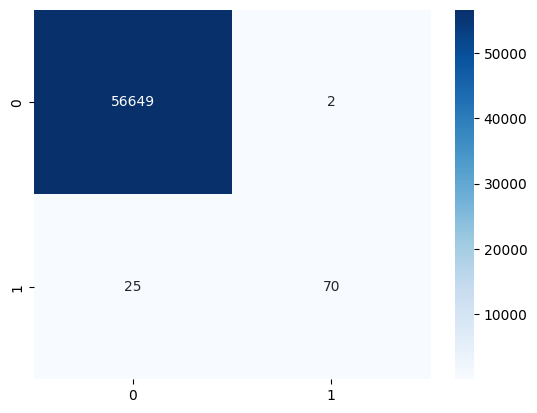

In [46]:

from sklearn.metrics import confusion_matrix

cm=confusion_matrix(y_test,pred)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.show()

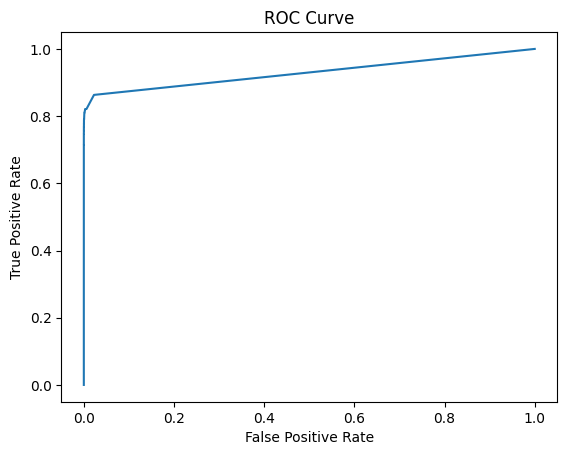

In [47]:
from sklearn.metrics import roc_curve

prob=rf.predict_proba(X_test)[:,1]

fpr,tpr,_=roc_curve(y_test,prob)

plt.plot(fpr,tpr)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.show()

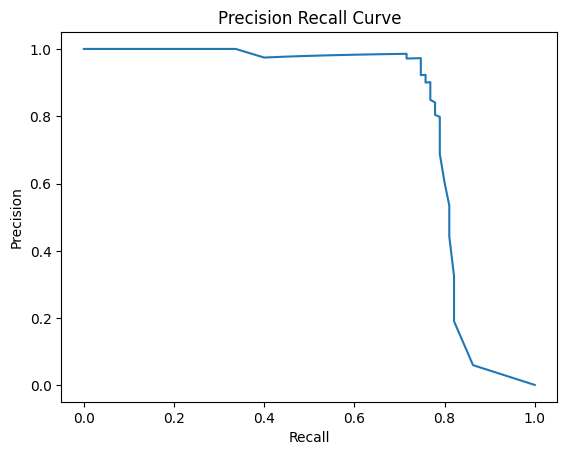

In [48]:
from sklearn.metrics import precision_recall_curve

precision,recall,_=precision_recall_curve(
    y_test,
    prob
)

plt.plot(recall,precision)

plt.xlabel("Recall")

plt.ylabel("Precision")

plt.title("Precision Recall Curve")

plt.show()

In [50]:
from sklearn.metrics import classification_report

pred1=lr.predict(X_test)

print(classification_report(y_test,pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.85      0.60      0.70        95

    accuracy                           1.00     56746
   macro avg       0.93      0.80      0.85     56746
weighted avg       1.00      1.00      1.00     56746



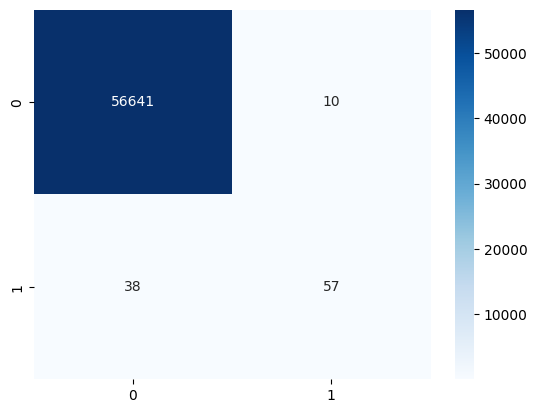

In [51]:

from sklearn.metrics import confusion_matrix

cm=confusion_matrix(y_test,pred1)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.show()

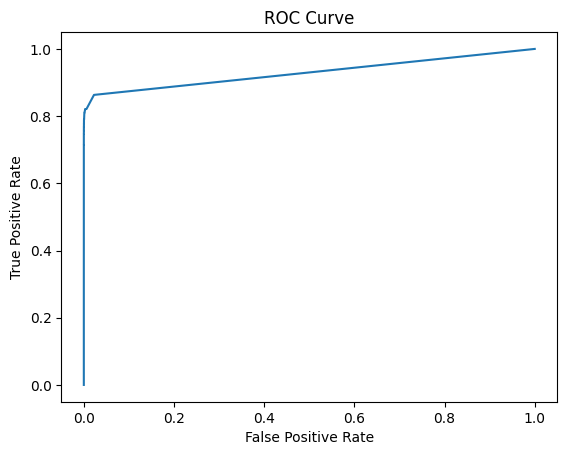

In [52]:
from sklearn.metrics import roc_curve

prob1=lr.predict_proba(X_test)[:,1]

fpr,tpr,_=roc_curve(y_test,prob)

plt.plot(fpr,tpr)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.show()

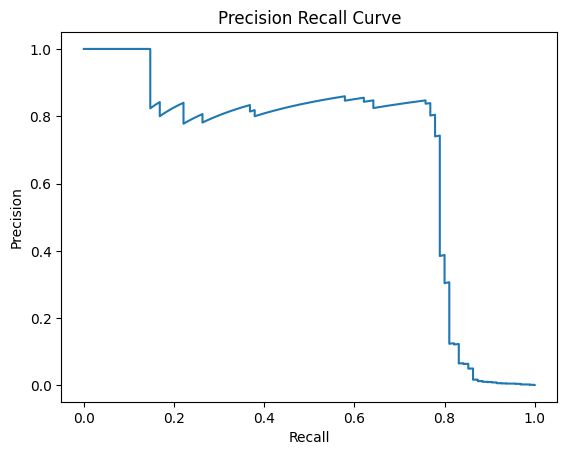

In [53]:
from sklearn.metrics import precision_recall_curve

precision,recall,_=precision_recall_curve(
    y_test,
    prob1
)

plt.plot(recall,precision)

plt.xlabel("Recall")

plt.ylabel("Precision")

plt.title("Precision Recall Curve")

plt.show()

In [54]:
from sklearn.metrics import classification_report

pred2=dt.predict(X_test)

print(classification_report(y_test,pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.85      0.60      0.70        95

    accuracy                           1.00     56746
   macro avg       0.93      0.80      0.85     56746
weighted avg       1.00      1.00      1.00     56746



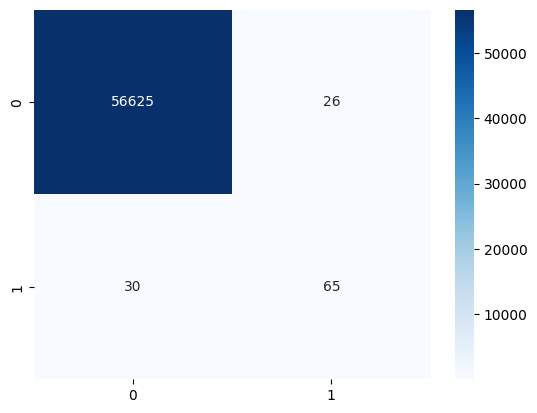

In [56]:
from sklearn.metrics import confusion_matrix

cm=confusion_matrix(y_test,pred2)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.show()

In [55]:
from sklearn.metrics import classification_report

pred3=xgb.predict(X_test)

print(classification_report(y_test,pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.85      0.60      0.70        95

    accuracy                           1.00     56746
   macro avg       0.93      0.80      0.85     56746
weighted avg       1.00      1.00      1.00     56746



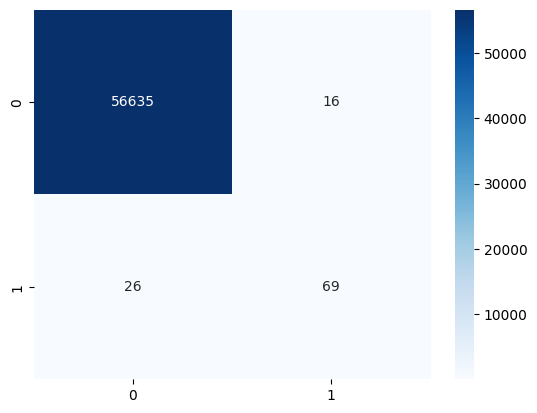

In [57]:
from sklearn.metrics import confusion_matrix

cm=confusion_matrix(y_test,pred3)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.show()

#XGBoost (Best Model)

#####Highest Precision (97.22%)
#####Highest Recall (73.68%)
######Highest F1-score (83.83%)
######Lowest False Positives (2)
Highest True Positives (70)

This is the strongest overall model for fraud detection.

# Hyperparameter Tuning

In [58]:
!pip install optuna

In [59]:
import optuna
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score

In [60]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [61]:
def objective(trial):

    params = {

        "n_estimators": trial.suggest_int(
            "n_estimators",
            100,
            500
        ),

        "learning_rate": trial.suggest_float(
            "learning_rate",
            0.01,
            0.3,
            log=True
        ),

        "max_depth": trial.suggest_int(
            "max_depth",
            3,
            12
        ),

        "subsample": trial.suggest_float(
            "subsample",
            0.6,
            1.0
        ),

        "colsample_bytree": trial.suggest_float(
            "colsample_bytree",
            0.6,
            1.0
        ),

        "gamma": trial.suggest_float(
            "gamma",
            0,
            5
        ),

        "min_child_weight": trial.suggest_int(
            "min_child_weight",
            1,
            10
        ),

        "reg_alpha": trial.suggest_float(
            "reg_alpha",
            0,
            5
        ),

        "reg_lambda": trial.suggest_float(
            "reg_lambda",
            0,
            5
        ),

        "objective": "binary:logistic",
        "eval_metric": "logloss",
        "random_state": 42,
        "n_jobs": -1
    }

    model = XGBClassifier(**params)

    score = cross_val_score(
        model,
        X_train_smote,
        y_train_smote,
        cv=cv,
        scoring="f1",
        n_jobs=-1
    ).mean()

    return score

In [62]:
study = optuna.create_study(direction="maximize")

[I 2026-07-13 13:54:02,416] A new study created in memory with name: no-name-20fde4b6-3fa0-4be8-a287-7c6f2bd9f223


In [63]:
study.optimize(
    objective,
    n_trials=20
)

[I 2026-07-13 13:56:10,739] Trial 0 finished with value: 0.9996051955073366 and parameters: {'n_estimators': 454, 'learning_rate': 0.18873566873488848, 'max_depth': 4, 'subsample': 0.8074340355731805, 'colsample_bytree': 0.8004302341967018, 'gamma': 0.7168154595702836, 'min_child_weight': 10, 'reg_alpha': 2.6068444550809704, 'reg_lambda': 1.0167510457858993}. Best is trial 0 with value: 0.9996051955073366.
[I 2026-07-13 13:57:17,653] Trial 1 finished with value: 0.9996911861200933 and parameters: {'n_estimators': 230, 'learning_rate': 0.12193376009664303, 'max_depth': 12, 'subsample': 0.8400806775235384, 'colsample_bytree': 0.7721481846310001, 'gamma': 1.9377876116835218, 'min_child_weight': 9, 'reg_alpha': 0.8269506639955448, 'reg_lambda': 2.408176437444922}. Best is trial 1 with value: 0.9996911861200933.
[I 2026-07-13 13:58:38,349] Trial 2 finished with value: 0.9994376553977791 and parameters: {'n_estimators': 344, 'learning_rate': 0.0998744173496114, 'max_depth': 5, 'subsample': 0

In [66]:
print(study.best_params)

{'n_estimators': 389, 'learning_rate': 0.11065777425986534, 'max_depth': 10, 'subsample': 0.9066711466320796, 'colsample_bytree': 0.6854470235905306, 'gamma': 0.05153404517739579, 'min_child_weight': 4, 'reg_alpha': 0.419821620458266, 'reg_lambda': 1.820522798595451}


In [67]:
from xgboost import XGBClassifier

best_model = XGBClassifier(
    n_estimators=389,
    learning_rate=0.11065777425986534,
    max_depth=10,
    subsample=0.9066711466320796,
    colsample_bytree=0.6854470235905306,
    gamma=0.05153404517739579,
    min_child_weight=4,
    reg_alpha=0.419821620458266,
    reg_lambda=1.820522798595451,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

best_model.fit(X_train_smote, y_train_smote)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.6854470235905306, device=None,
              early_stopping_rounds=None, enable_categorical=True,
              eval_metric='logloss', feature_types=None, feature_weights=None,
              gamma=0.05153404517739579, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.11065777425986534,
              max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=10, max_leaves=None,
              min_child_weight=4, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=389, n_jobs=-1,
              num_parallel_tree=None, ...)

In [68]:
y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

In [69]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.82      0.79      0.80        95

    accuracy                           1.00     56746
   macro avg       0.91      0.89      0.90     56746
weighted avg       1.00      1.00      1.00     56746



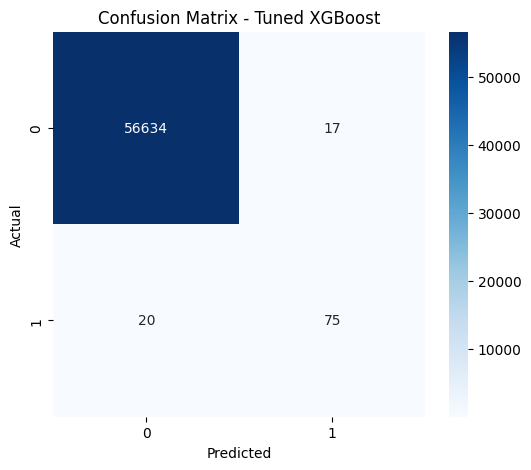

In [70]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm,
            annot=True,
            fmt="d",
            cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Tuned XGBoost")
plt.show()

In [71]:
from sklearn.metrics import roc_auc_score

roc_auc = roc_auc_score(y_test, y_prob)

print("ROC-AUC Score:", roc_auc)

ROC-AUC Score: 0.9696442391038761


In [72]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": best_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(10)

,Feature,Importance
13,V14,0.456040
9,V10,0.161374
16,V17,0.092362
3,V4,0.040326
11,V12,0.038573
7,V8,0.015372
2,V3,0.014748
17,V18,0.012684
6,V7,0.012444
10,V11,0.012046


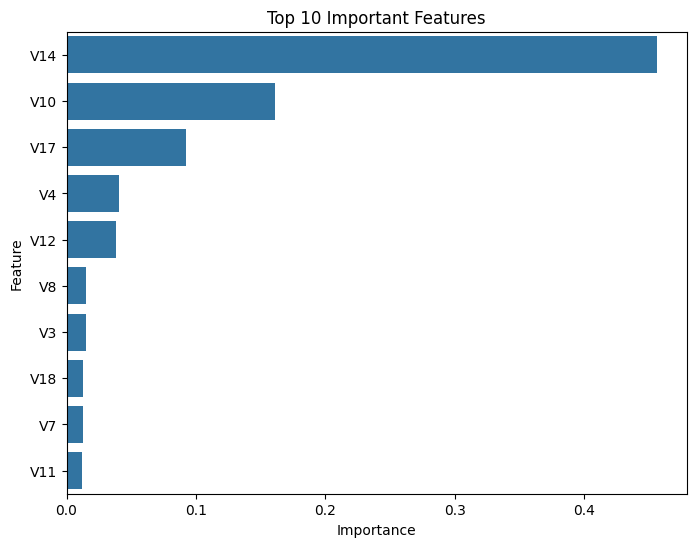

In [73]:
plt.figure(figsize=(8,6))

sns.barplot(
    data=importance.head(10),
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Important Features")
plt.show()

In [74]:
!pip install shap

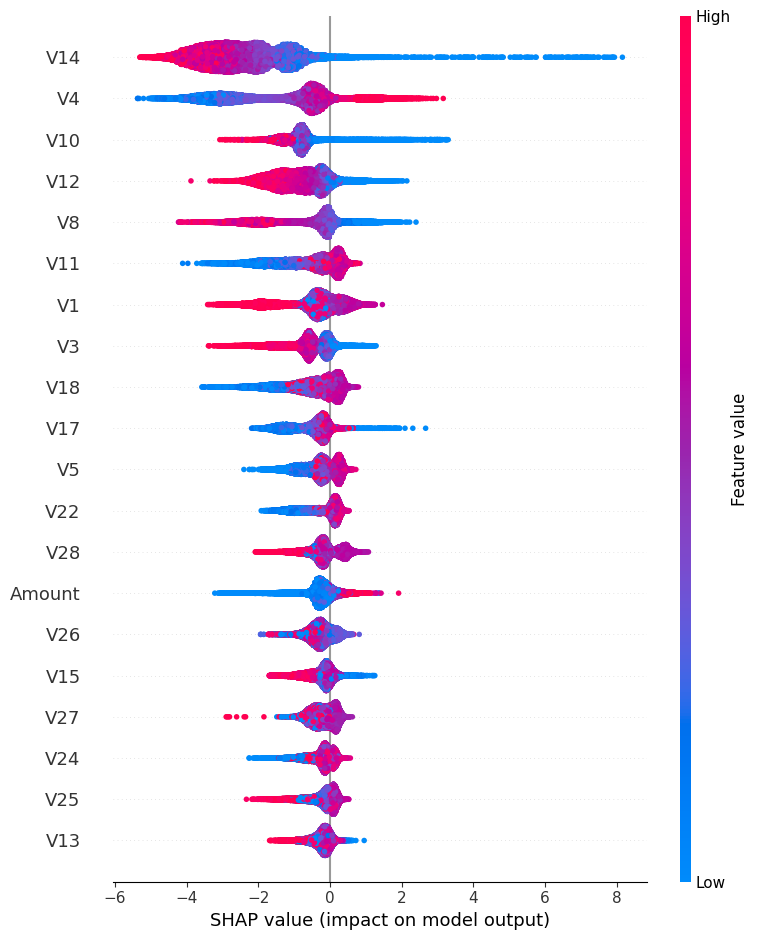

In [75]:
import shap

explainer = shap.TreeExplainer(best_model)

shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test)

In [76]:
import joblib

joblib.dump(best_model, "fraud_detection_model.pkl")

['fraud_detection_model.pkl']